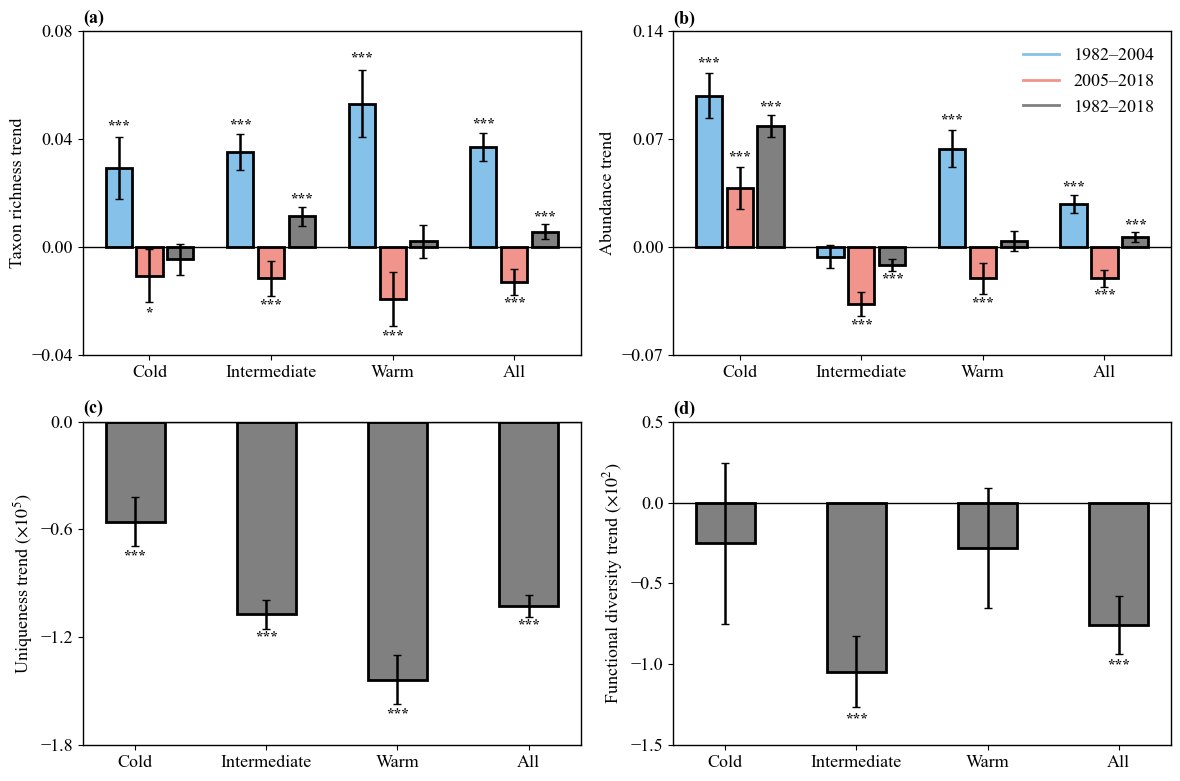

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 13,
    "mathtext.fontset": "stix",
    "axes.linewidth": 1,
    "axes.edgecolor": "black",
    "axes.grid": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.color": "black",
    "ytick.color": "black",
})

df_rich = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Richness_slopes_summary.csv")
df_abun = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Abundance_slopes_summary.csv")
df_lcbd = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\LCBD_slopes_summary.csv")
df_fd   = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\FD_slopes_summary.csv")

zones = ["Cold", "Intermediate", "Warm", "All"]
periods = ["early", "late", "full"]
period_labels = ["1982–2004", "2005–2018", "1982–2018"]
period_colors = ["#86c1ea", "#f1948b", "gray"]

bar_width = 0.28
gap = 0.05

offsets = {
    "early": -(bar_width + gap),
    "late":  0.0,
    "full":  +(bar_width + gap),
}

group_gap = 1.3
x_base = np.arange(len(zones)) * group_gap


def plot_period_panel(ax, df, ylabel, panel_label):

    for per, color in zip(periods, period_colors):

        xpos = x_base + offsets[per]
        sub = df[df.period == per].set_index("zone")

        means = sub.loc[zones, "slope"].values
        ses   = sub.loc[zones, "SE"].values
        sigs  = sub.loc[zones, "sig"].values

        for i in range(len(zones)):

            mean = means[i]
            se   = ses[i]
            star = sigs[i]

            ax.bar(
                xpos[i], mean,
                width=bar_width,
                facecolor=color,
                edgecolor='black',
                linewidth=2
            )

            ax.errorbar(
                xpos[i], mean,
                yerr=se * 1.96,
                fmt="none",
                ecolor='black',
                elinewidth=1.8,
                capsize=3
            )

            if isinstance(star, str) and star.strip() != "":
                y = mean + np.sign(mean) * se * 1.96 * 1.15
                ax.text(
                    xpos[i], y, star,
                    ha="center",
                    va="bottom" if mean >= 0 else "top",
                    fontsize=11,
                    fontweight="bold"
                )

    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(x_base)
    ax.set_xticklabels(zones)
    ax.set_ylabel(ylabel)
    ax.set_title(panel_label, loc="left", fontsize=13, fontweight="bold")

def plot_full_panel(ax, df, ylabel, panel_label, scale):

    x = np.arange(len(zones))
    sub = df[df["period"] == "full"].set_index("zone")

    means = sub.loc[zones, "slope"].values * scale
    ses   = sub.loc[zones, "SE"].values * scale
    sigs  = sub.loc[zones, "sig"].values

    ax.bar(
        x, means,
        width=0.45,
        facecolor="gray",
        edgecolor="black",
        linewidth=2
    )

    ax.errorbar(
        x, means,
        yerr=ses * 1.96,
        fmt="none",
        ecolor="black",
        elinewidth=1.8,
        capsize=3
    )

    for i, star in enumerate(sigs):
        if isinstance(star, str) and star.strip() != "":
            y = means[i] + np.sign(means[i]) * ses[i] * 1.96 * 1.15
            ax.text(
                x[i], y, star,
                ha="center",
                va="bottom" if means[i] >= 0 else "top",
                fontsize=11,
                fontweight="bold"
            )

    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(zones)
    ax.set_ylabel(ylabel)
    ax.set_title(panel_label, loc="left", fontsize=13, fontweight="bold")


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
plot_period_panel(
    axes[0, 0],
    df_rich,
    ylabel="Taxon richness trend",
    panel_label="(a)"
)
axes[0, 0].set_ylim(-0.04, 0.08)
axes[0, 0].set_yticks(np.arange(-0.04, 0.09, 0.04))
plot_period_panel(
    axes[0, 1],
    df_abun,
    ylabel="Abundance trend",
    panel_label="(b)"
)
axes[0, 1].set_ylim(-0.07, 0.14)
axes[0, 1].set_yticks(np.arange(-0.07, 0.15, 0.07))
plot_full_panel(
    axes[1, 0],
    df_lcbd,
    ylabel=r"Uniqueness trend ($\times 10^{5}$)",
    panel_label="(c)",
    scale=1e5
)
axes[1, 0].set_ylim(-1.8, 0.0)
axes[1, 0].set_yticks(np.arange(-1.8, 0.01, 0.6))
plot_full_panel(
    axes[1, 1],
    df_fd,
    ylabel=r"Functional diversity trend ($\times 10^{2}$)",
    panel_label="(d)",
    scale=1e2
)
axes[1, 1].set_ylim(-1.5, 0.5)
axes[1, 1].set_yticks(np.arange(-1.5, 0.6, 0.5))
handles = [
    plt.Line2D([0], [0], color=period_colors[0], lw=2),
    plt.Line2D([0], [0], color=period_colors[1], lw=2),
    plt.Line2D([0], [0], color=period_colors[2], lw=2),
]

axes[0, 1].legend(
    handles,
    period_labels,
    frameon=False,
    loc="upper right"
)

plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\extendFig5.png", dpi=500, bbox_inches="tight")
plt.show()
